In [2]:
from torchvision import datasets

ds_train = datasets.CIFAR10(root="/tmp", download=True, train=True)
ds_val = datasets.CIFAR10(root="/tmp", download=True, train=False)

In [3]:
len(ds_train), len(ds_val)

(50000, 10000)

In [4]:
from numpy.lib.format import open_memmap

scores = open_memmap("./slurm_example_results/scores/slurm_example.mmap")

In [5]:
scores

memmap([[-2.354  , -0.5312 , -0.0482 , ..., -0.1442 ,  0.692  , -0.01075],
        [ 2.732  , -0.58   ,  0.505  , ..., -0.0883 , -0.884  , -0.1813 ],
        [-0.563  , -0.282  , -0.537  , ...,  1.537  , -1.412  , -0.1995 ],
        ...,
        [-0.3005 , -0.603  ,  0.5537 , ...,  0.2081 ,  0.882  ,  0.1216 ],
        [-0.0855 , -1.225  , -0.7163 , ...,  0.4854 , -2.006  ,  0.0984 ],
        [ 0.13   , -0.9844 , -0.566  , ...,  0.1444 , -1.497  ,  0.2537 ]],
       shape=(50000, 10000), dtype=float16)

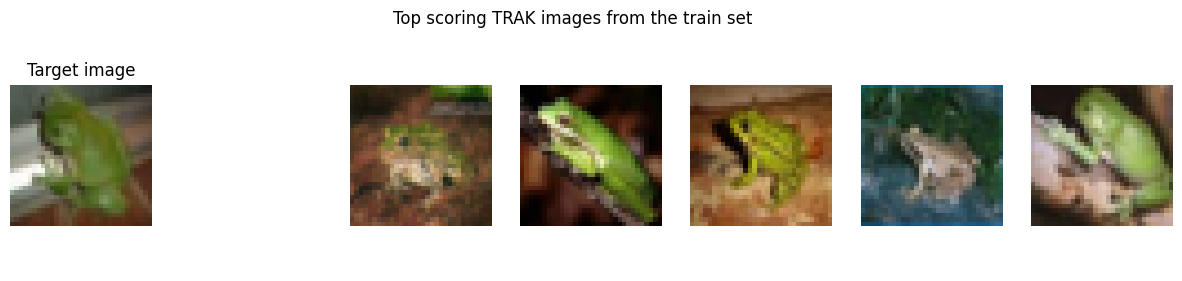

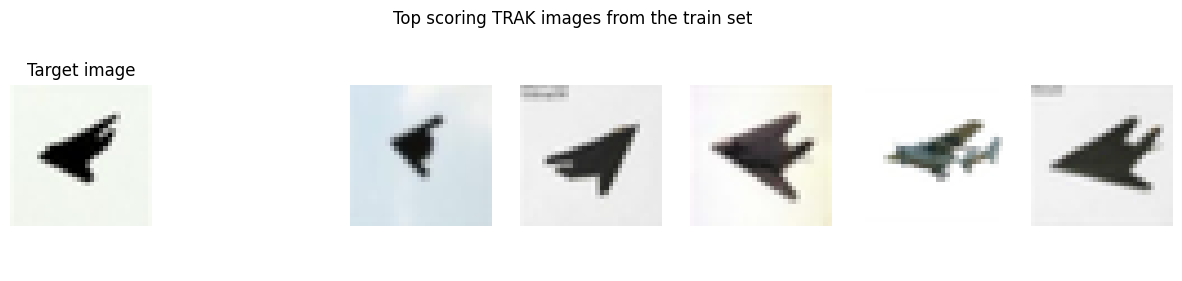

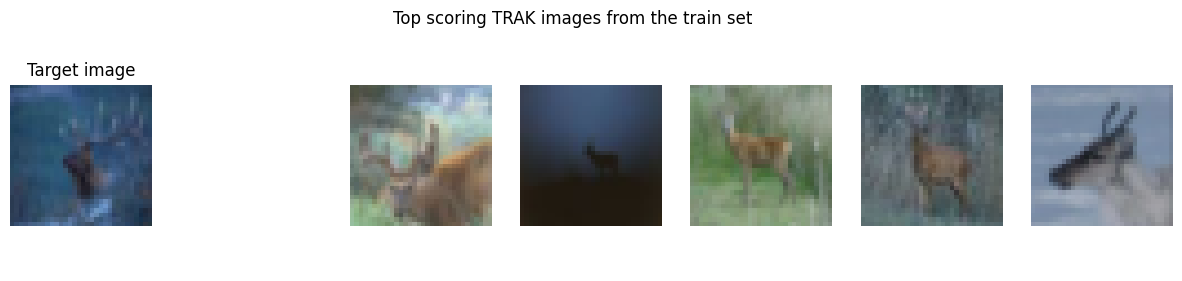

In [6]:
from matplotlib import pyplot as plt

for i in [7, 21, 22]:

	fig, axs = plt.subplots(ncols=7, figsize=(15, 3))
	fig.suptitle('Top scoring TRAK images from the train set')
	
	axs[0].imshow(ds_val[i][0])
	axs[0].axis('off')
	axs[0].set_title('Target image')
	
	axs[1].axis('off')
	
	top_trak_scorers = scores[:, i].argsort()[-5:][::-1]
	for ii, train_im_ind in enumerate(top_trak_scorers):
		axs[ii + 2].imshow(ds_train[train_im_ind][0])
		axs[ii + 2].axis('off')

	fig.show()